### Loading Training and Test Data

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

feature_train = pd.read_csv('X_train_prepared.csv',  index_col=0)
target_train = pd.read_csv('y_train_prepared.csv', index_col=0).squeeze()
feature_test = pd.read_csv('X_test_processed.csv',  index_col=0)
target_test = pd.read_csv('y_test.csv', index_col=0).squeeze()

In [4]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42
)
rf_model.fit(feature_train, target_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### Prediction

In [5]:
y_pred_train = rf_model.predict(feature_train)
y_pred_test  = rf_model.predict(feature_test)

### Calculation MAE, RMSE and R²

In [6]:
mae  = mean_absolute_error(target_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(target_test, y_pred_test))
r2   = r2_score(target_test, y_pred_test)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  64.2720
RMSE: 85.1451
R²:   0.9131


MAE: 64 is a good value for our model
RMSE: 85 is a good value but it means that our model makes mistakes when predicting for more isolated cases 
R^2: 0.91 it is a very good value, and it means that 91% percent of the variable variation is explained by our model 

### Plotting and Calculating for Analysing

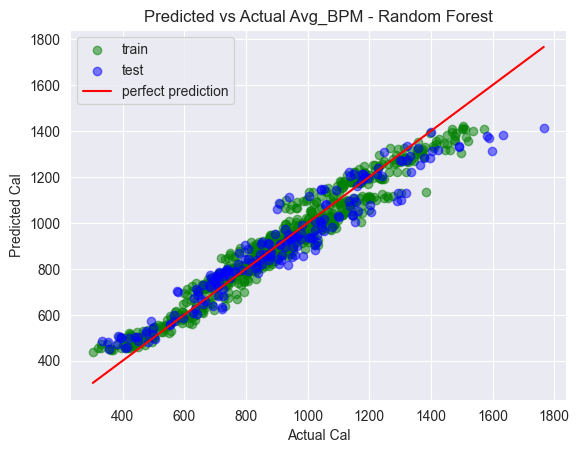

In [7]:
min_val = min(target_train.min(), target_test.min())
max_val = max(target_train.max(), target_test.max())

plt.scatter(target_train, y_pred_train, c='green', label='train', alpha=0.5)
plt.scatter(target_test,  y_pred_test,  c='blue',  label='test',  alpha=0.5)
plt.plot([min_val, max_val], [min_val, max_val], c='red', label='perfect prediction')

plt.xlabel('Actual Cal')
plt.ylabel('Predicted Cal')
plt.legend()
plt.title('Predicted vs Actual Calories - Random Forest')
plt.show()


This plot shows us that we have a pretty strong overall accuracy, but our model struggles to predict high values(above 1400)

### Residual Distribution

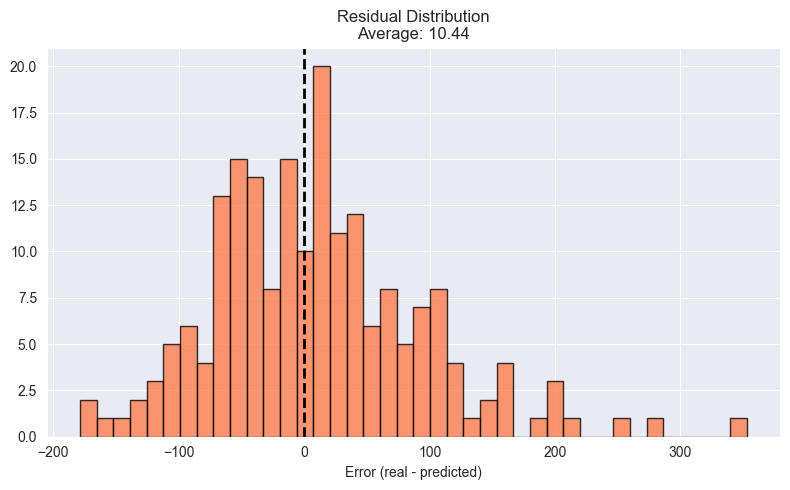

In [20]:
residuals = target_test.values - y_pred_test

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=40, color='coral', edgecolor='black', alpha=0.8)
plt.axvline(0, color='black', linestyle='--', lw=2)
plt.xlabel("Error (real - predicted)")
plt.title(f"Residual Distribution\nAverage: {residuals.mean():.2f}")
plt.tight_layout()
plt.savefig('residual_distribution.png', dpi=150)
plt.show()

Our model slightly underestimates the number of calories burned (avg = 10.44).

### Feature Importance 

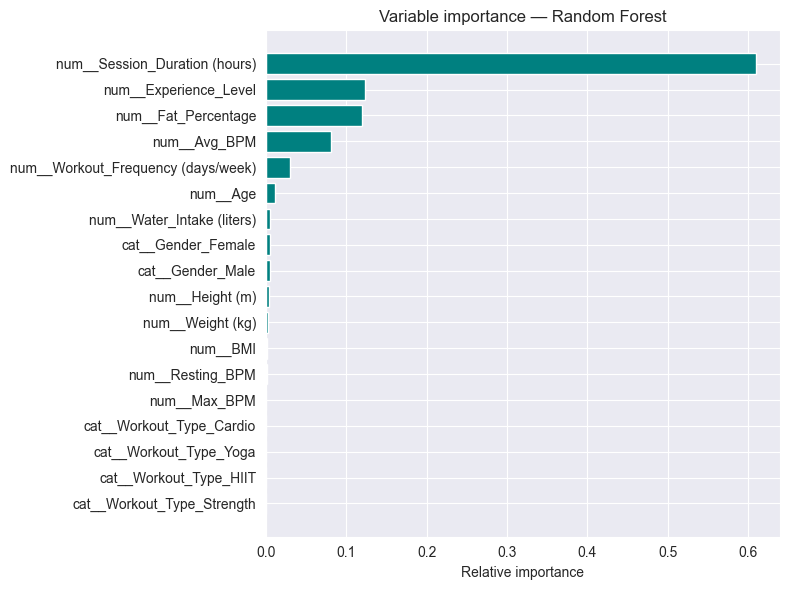

In [19]:
importance = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': feature_train.columns,
    'Importance': importance
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='teal')
plt.title("Variable importance — Random Forest")
plt.xlabel("Relative importance")
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

The most relevant column for our model is session duration, followed by experience level and fat percentage, with o short gap between the two of them.

### Learning Curve



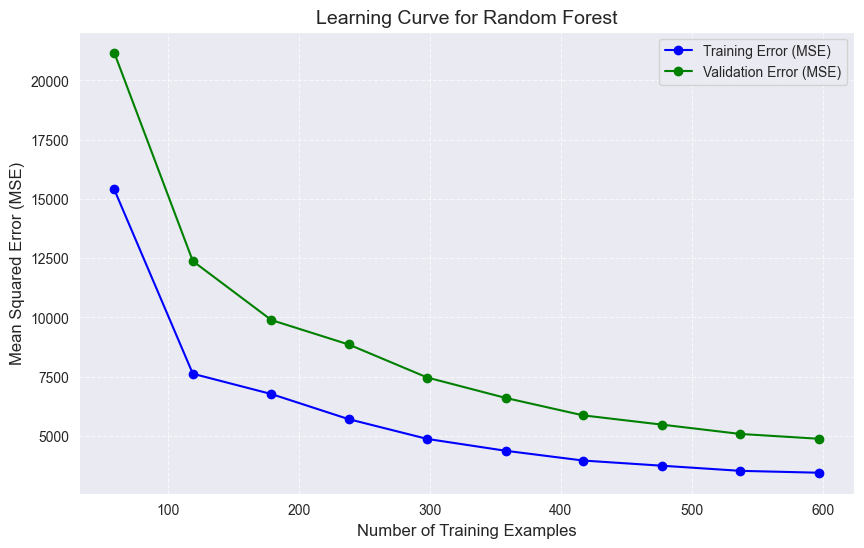

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Calculate scores for the learning curve using rf_model
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, 
    feature_train, 
    target_train, 
    cv=5, # 5-fold cross-validation
    scoring='neg_mean_squared_error', # Using MSE
    train_sizes=np.linspace(0.1, 1.0, 10), # From 10% to 100% of the training data
    n_jobs=-1 # Use all available CPU cores
)

# Convert negative scores to positive MSE
train_mean = -np.mean(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Error (MSE)')
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Validation Error (MSE)')
plt.xlabel('Number of Training Examples', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Learning Curve for Random Forest', fontsize=14)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The gap between the training and validation error is not high, so the overfitting is normal. However, we need more data in order to get them converged to each other. 

### Decision tree visualization 

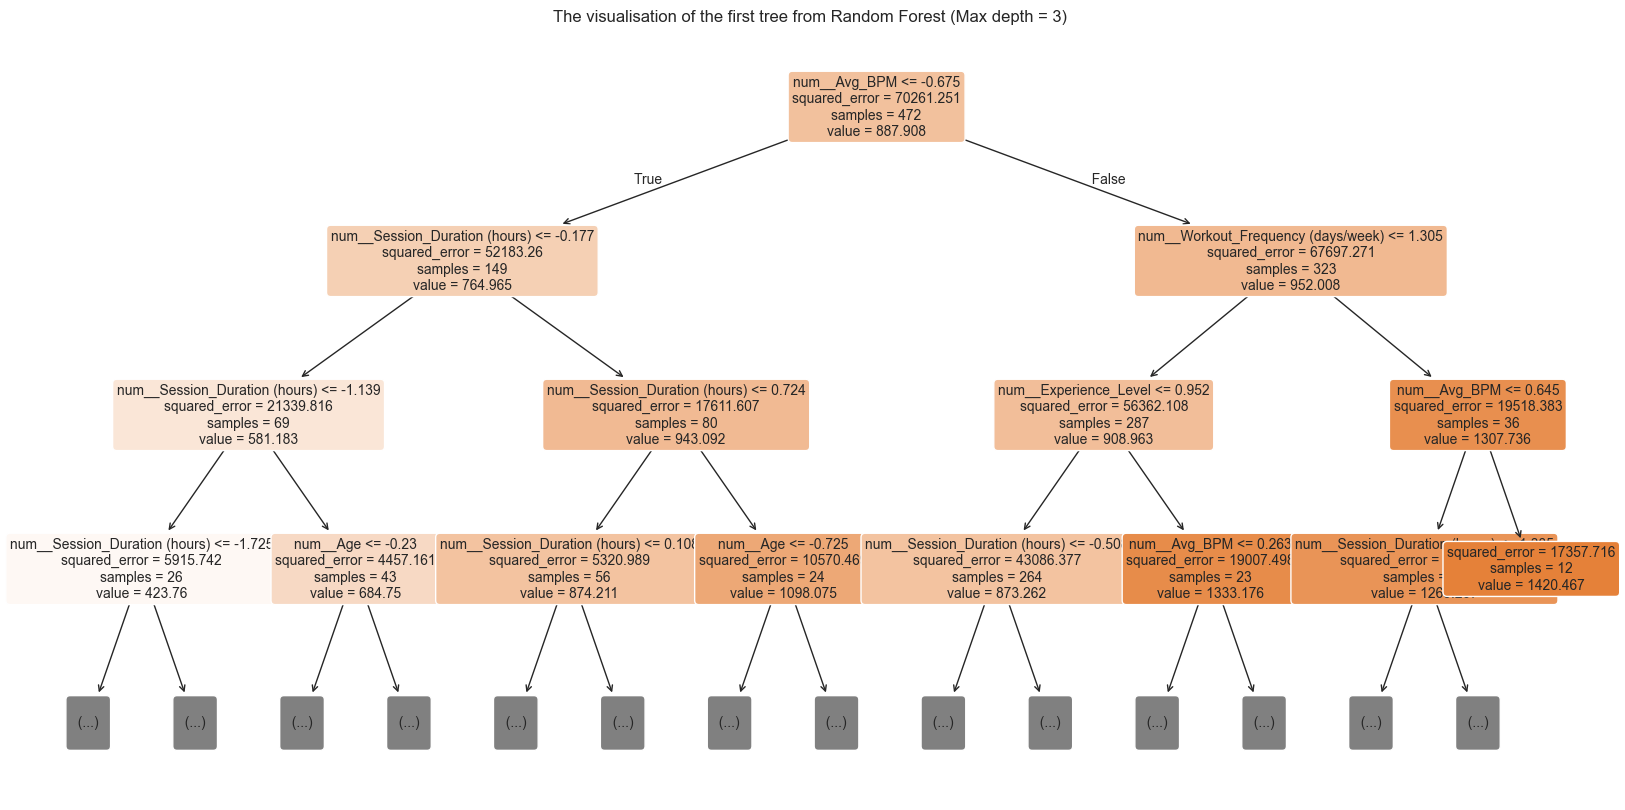

In [31]:
from sklearn.tree import plot_tree


single_tree = rf_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    single_tree, 
    feature_names=feature_train.columns, 
    filled=True, 
    rounded=True, 
    max_depth=3,
    fontsize=10
)
plt.title("The visualisation of the first tree from Random Forest (Max depth = 3)")
plt.show()